In [6]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [7]:
def fc_matrix(ts):
    n = ts.shape[1]
    fc = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            fc[i, j] = np.corrcoef(ts[:, i], ts[:, j])[0, 1]
    return fc

def FCuCorrelation(FC1, FC2, fisher=True):
    u_idx = np.triu_indices_from(FC1, k=1)
    FCu1 = FC1.copy()[u_idx]
    FCu2 = FC2.copy()[u_idx]
    if fisher:
        FCu1 = np.arctanh(FCu1)
        FCu2 = np.arctanh(FCu2)
    FC_corr_upper = np.corrcoef(FCu1, FCu2)[0, 1]
    return FC_corr_upper

In [8]:
ts_fname = "/home/david-daubner/Desktop/NMDARE/bids/derivatives/xcp_d/sub-LENMDA002/func/sub-LENMDA002_task-rest_space-fsLR_seg-Glasser_den-91k_stat-mean_timeseries.ptseries.nii"
fc_fname = "/home/david-daubner/Desktop/NMDARE/bids/derivatives/xcp_d/sub-LENMDA002/func/sub-LENMDA002_task-rest_space-fsLR_seg-Glasser_den-91k_stat-pearsoncorrelation_boldmap.pconn.nii"

In [12]:
time_series = nib.load(ts_fname).dataobj
time_series.shape

(260, 360)

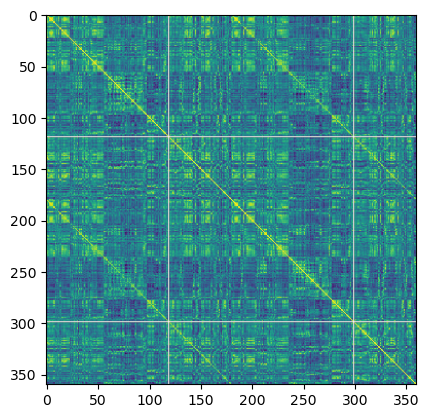

In [13]:
static_fc = fc_matrix(time_series)
plt.imshow(static_fc)

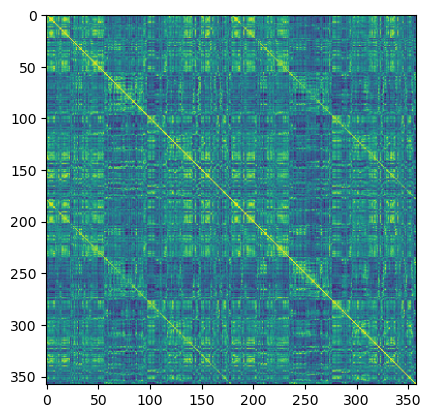

In [59]:
static_fc = np.delete(static_fc, [119, 299], 1)
static_fc = np.delete(static_fc, [119, 299], 0)
plt.imshow(static_fc)

In [52]:
np.argwhere(np.isnan(all_fcs[1].flatten()))

array([[   119],
       [   299],
       [   479],
       ...,
       [129179],
       [129359],
       [129539]], shape=(1436, 1))

In [47]:
len([x for x in FCu1 if np.isnan(x)])

717

In [ ]:

np.corrcoef(all_fcs[1], all_fcs[0])

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(720, 720))

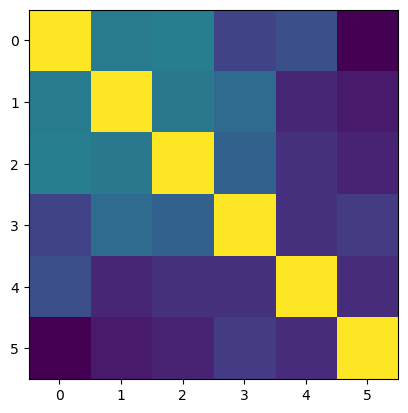

In [60]:
window_size = 40
window_step = 40

all_fcs = []
for i in range(0, time_series.shape[0] - window_size, window_step):
    window_ts = time_series[i:i + window_size, :]

    fc = fc_matrix(window_ts)
    fc = np.delete(fc, [119, 299], 1)
    fc = np.delete(fc, [119, 299], 0)

    all_fcs.append(fc)

n_fcs = len(all_fcs)

FCD = np.zeros((n_fcs, n_fcs))
for i in range(n_fcs):
    for j in range(n_fcs):
        FCD[i, j] = FCuCorrelation(all_fcs[i], all_fcs[j])

plt.imshow(FCD)

(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 2., 0., 0., 0., 0., 2., 0., 2., 2.,
        0., 2., 4., 0., 2., 0., 2., 0., 0., 2., 0., 0., 0., 0., 2., 0., 0.,
        2., 0., 0., 0., 2., 2., 2., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 6.]),
 array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
        0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
        0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
        0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
        0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
        0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
        0.77, 0.78, 0.79, 0.8 , 

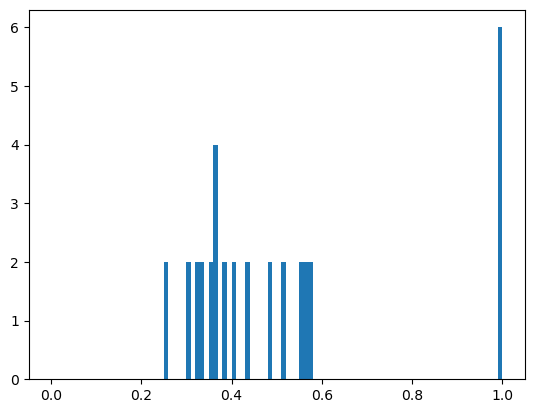

In [61]:
fcd_flattened = FCD.flatten()
plt.hist(fcd_flattened, bins=100, range=(0, 1))